# Stochastic Expectation-Maximization


In [1]:
%load_ext autoreload
%autoreload 2
from functools import cache
import importlib
import scipy.special as ss
import functools
import xgi
import math
from collections import Counter, defaultdict
m = importlib.import_module(".model", "src")
#mn = importlib.import_module(".model_new", "src")
sem = importlib.import_module(".sem", "src") 
#semn = importlib.import_module(".sem_new", "src") 
em = importlib.import_module(".em", "src")
ll = importlib.import_module(".likelihoods", "src")
from matplotlib import pyplot as plt
import numpy as np
import pickle

def expectation(x):
    
    to_sum = [(i)*j for i,j in enumerate(x)]
      
    return sum(to_sum)

eta   = 0.7   # node retention in edges
beta  = [0.71, 0.21, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01]
gamma = [0.3, 0.2, 0.1, 0.05, 0.05, 0.02, 0.02, 0.02, 0.02, 0.02, 
        0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01,0.01, 0.01, 0.01, 
        0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01,0.01, 0.01, 0.01]
expectation(gamma)

C:\Users\hexie\.conda\envs\Hgraph\lib\site-packages\xgi\__init__.py:1: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources
C:\Users\hexie\.conda\envs\Hgraph\lib\site-packages\xgi\utils\utilities.py:9: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


5.35

In [32]:
# timesteps = int(1e6)
# rk = []

# for cc in range(timesteps):
    
#     if cc%100 == 0:
#         with open('simulation_1/r_{}.pkl'.format(cc), 'rb') as fp:
#             r = pickle.load(fp)

#         i_size = max([x[0] for x in r.keys()])
#         j_size = max([x[1] for x in r.keys()])
#         k_size = max([x[2] for x in r.keys()])


#         #print(i_size, j_size, k_size) 

#         r_ijk = np.zeros(shape=(i_size+1, j_size+1, k_size+1))

#         for key in r.keys():
#             r_ijk[key] = r[key]

#         # Transpose the array to bring the first two axes to the end
#         array_transposed = np.transpose(r_ijk, (2, 0, 1))
#         # Apply np.triu along the last two axes
#         upper_triangle_transposed = np.triu(array_transposed)
#         # Transpose the result back to the original shape
#         upper_triangle = np.transpose(upper_triangle_transposed, (1, 2, 0))


#         normalized_rijk = upper_triangle/np.sum(upper_triangle)

#         rk.append(np.sum(normalized_rijk, axis = (0,1)))
        
# rk = np.array(rk)
# np.save("rk.npy", rk)

88 88 66


array([9.64927839e-01, 3.31860684e-02, 1.62833206e-03, 1.74807828e-04,
       4.07847766e-05, 1.60560068e-05, 8.35259268e-06, 5.01481184e-06,
       3.26278621e-06, 2.24631001e-06, 1.60958385e-06, 1.18563519e-06,
       8.93304186e-07, 6.89554457e-07, 5.39889273e-07, 4.26277120e-07,
       3.40330361e-07, 2.74831590e-07, 2.23827644e-07, 1.82799644e-07,
       1.49611173e-07, 1.24614299e-07, 1.01849860e-07, 8.49505646e-08,
       7.14279278e-08, 5.90195082e-08, 4.91435825e-08, 4.07559470e-08,
       3.39986294e-08, 2.83655310e-08, 2.31685176e-08, 1.89196892e-08,
       1.58510908e-08, 1.31345611e-08, 1.07280919e-08, 8.91573848e-09,
       7.16539718e-09, 5.85714209e-09, 4.66691000e-09, 3.97877582e-09,
       3.00058509e-09, 2.36246066e-09, 1.82435573e-09, 1.55230268e-09,
       1.15222467e-09, 1.03620205e-09, 7.06137690e-10, 5.28102975e-10,
       4.38085422e-10, 2.86055778e-10, 2.02039396e-10, 1.64031985e-10,
       1.42027694e-10, 8.00156023e-11, 8.80171625e-11, 4.00078011e-11,
      

In [2]:
r1 = np.load("rk_1.npy", allow_pickle=True)
r2 = np.load("rk_2.npy", allow_pickle=True)
r3 = np.load("rk_3.npy", allow_pickle=True)


In [5]:
def plot_intersection(data, name):
    for i in range(0, 10):
        k0 = [x[i] for x in data[50:]]
        plt.plot(range(50,10000), k0, label = "k = " + str(i))
        
    plt.legend()
    plt.loglog()
    plt.title(name)
    plt.xlabel("log scaled time")
    plt.ylabel("Probablity of rk")
    #plt.savefig("figures/rk_plot_{}.pdf".format(name))
    plt.show()
    plt.close()

$\eta = $0.7$, \beta = $0.65$, \gamma = $5.35


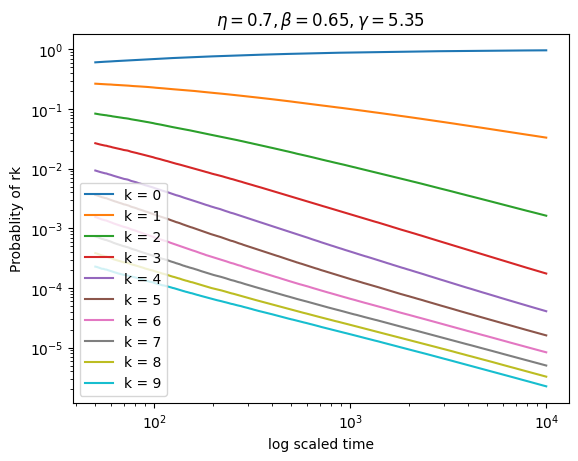

In [6]:
lab = r"$\eta = $" + str(0.7) + r"$, \beta = $" + str(0.65) + r"$, \gamma = $" + str(5.35) 

print(lab)
plot_intersection(r1,lab)


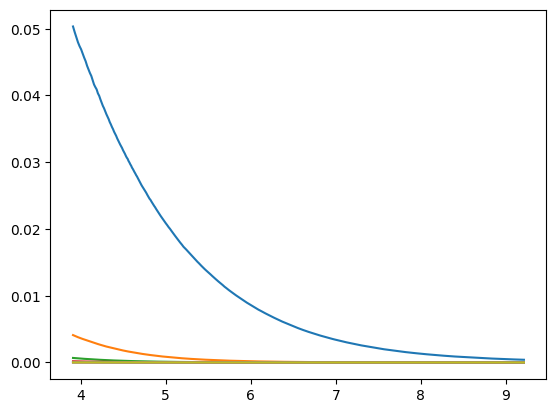

In [5]:
plot_intersection(r2)

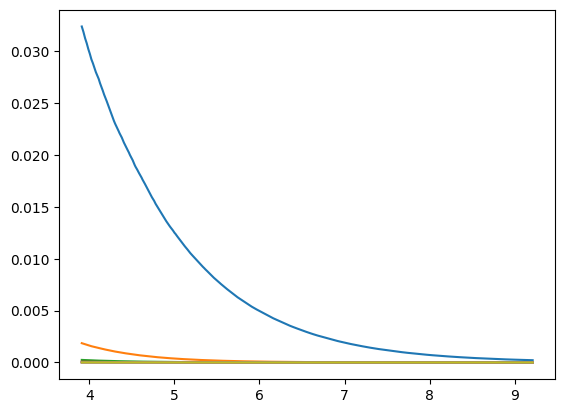

In [6]:
plot_intersection(r3)